<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

--2026-01-20 08:11:32--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv.3’

survey-data.csv.3   100%[===================>] 152.13M  68.6MB/s    in 2.2s    

2026-01-20 08:11:36 (68.6 MB/s) - ‘survey-data.csv.3’ saved [159525875/159525875]



**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 87.2 MB/s eta 0:00:00


**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [3]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [4]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
#conn.close()


65437

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [5]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time       None  Apples   
4   Student, full-time       None  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                               None   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [6]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [7]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [9]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [10]:
## Write your code here
df.head()

,sql
0,"CREATE TABLE ""main"" (\n""ResponseId"" INTEGER,\n..."


In [11]:
q = """
SELECT CompTotal
FROM main
"""
df = pd.read_sql_query(q, conn)

In [12]:
!pip install seaborn
import seaborn as sns

In [13]:
import numpy as np

In [14]:
df.dtypes
df['CompTotal']=df['CompTotal'].astype(float)

In [15]:
df.dropna(inplace=True)

In [16]:
df

,CompTotal
72,2040000.0
374,28000.0
379,85000.0
385,50000.0
389,110000.0
...,...
65396,36000.0
65401,40000.0
65408,61000.0
65412,58000.0


In [17]:
df = df.drop(df[df['CompTotal'] == 0].index)

In [18]:
q1= df['CompTotal'].quantile(0.25)
q3= df['CompTotal'].quantile(0.75)
iqr=q3-q1
up = q3+1.5*iqr
out=df[df['CompTotal'] > up].index

In [19]:
df=df.drop(out)

In [20]:
df['CompTotal_log'] = np.log10(df['CompTotal'])

(0.0, 561749.9500000001)

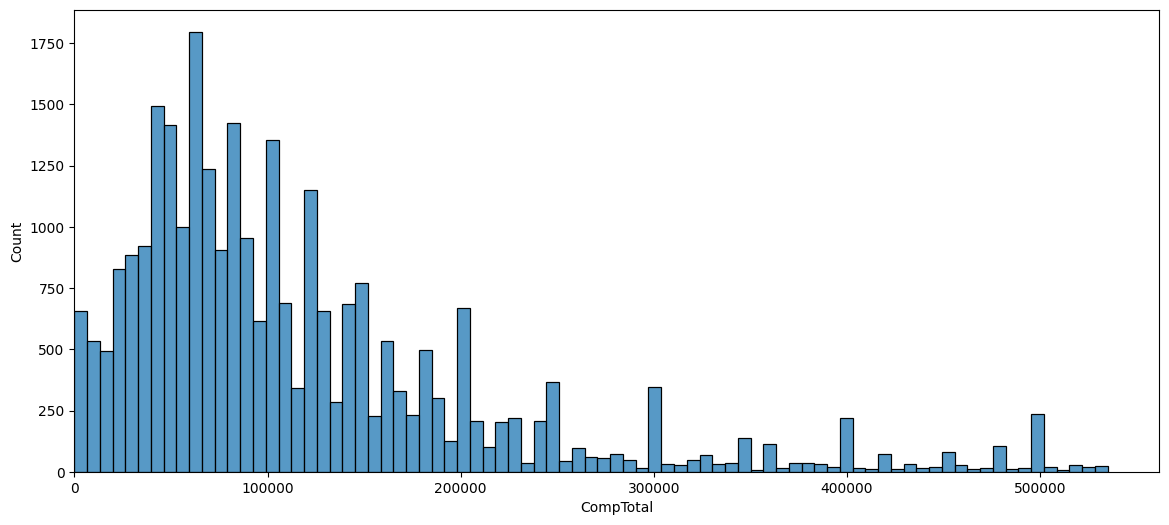

In [21]:
plt.figure(figsize=(14,6))
sns.histplot(df, x='CompTotal')
plt.xlim(0,)

**Box Plots**

Plot a box plot of Age.


In [22]:
## Write your code here
q = '''
SELECT Age
FROM main
'''
df = pd.read_sql_query(q, conn)

In [23]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [24]:
df=df.dropna()

In [25]:
df['Age'].value_counts()

Age
29.5    23911
39.5    14942
21.0    14098
49.5     6249
59.5     2575
16.0     2568
72.5      772
Name: count, dtype: int64

<Axes: >

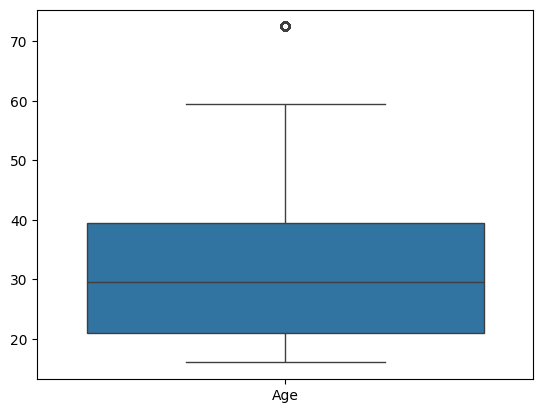

In [26]:
sns.boxplot(df)

### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


In [27]:
## Write your code here
q='''
SELECT Age, WorkExp
FROM main
'''
df=pd.read_sql_query(q, conn)

In [28]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [29]:
df['WorkExp'].isnull().value_counts()

WorkExp
True     35779
False    29658
Name: count, dtype: int64

In [30]:
df['WorkExp'] = df['WorkExp'].replace(np.nan, df['WorkExp'].median())

In [31]:
df['Age']=df['Age'].dropna()

In [32]:
df['Age_n'] = df['Age']/5
df['WorkExp'].max()

np.float64(50.0)

In [33]:
bins=np.linspace(min(df['WorkExp']), max(df['WorkExp']), 11)
gr_n=['0-5', '6-10', '11-15', '16-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50']
df['WorkExpBin']=pd.cut(df['WorkExp'],bins,labels=gr_n, include_lowest=True)
df

,Age,WorkExp,Age_n,WorkExpBin
0,16.0,9.0,3.2,6-10
1,39.5,17.0,7.9,16-20
2,49.5,9.0,9.9,6-10
3,21.0,9.0,4.2,6-10
4,21.0,9.0,4.2,6-10
...,...,...,...,...
65432,21.0,9.0,4.2,6-10
65433,29.5,9.0,5.9,6-10
65434,29.5,9.0,5.9,6-10
65435,21.0,5.0,4.2,0-5


<Axes: xlabel='WorkExp', ylabel='Age_n'>

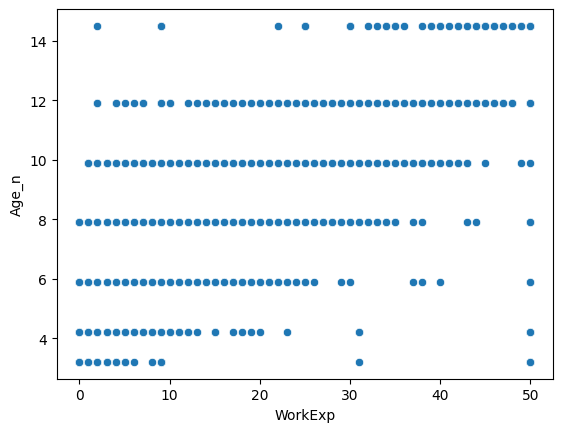

In [34]:
sns.scatterplot(df, x='WorkExp', y='Age_n')

**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [35]:
## Write your code here
q='''
SELECT TimeSearching, Frustration, Age
FROM main 
'''
df=pd.read_sql_query(q, conn)

In [36]:
df.isnull().sum()

TimeSearching    36526
Frustration      37186
Age                  0
dtype: int64

In [37]:
df['TimeSearching'].value_counts()

TimeSearching
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: count, dtype: int64

In [38]:
time_map={'Less than 15 minutes a day' : 7.5,
          '15-30 minutes a day' : (30+15)/2,
          '30-60 minutes a day' : (30+60)/2,
          '60-120 minutes a day' : (60+120)/2,
          'Over 120 minutes a day' :(120+200)/2}
df['TimeSearching']=df['TimeSearching'].map(time_map)

In [39]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [40]:
df['F_count']=df['Frustration'].str.split(';').str.len()
#ex=df.explode('Frustration').reset_index(drop=True)

In [41]:
df['TimeSearching']=df['TimeSearching']/10

In [42]:
df.dropna(inplace=True)

In [43]:
df

,TimeSearching,Frustration,Age,F_count
10,4.50,Amount of technical debt;Number of software to...,39.5,4.0
12,4.50,Amount of technical debt;Complexity of tech st...,39.5,2.0
15,9.00,Amount of technical debt;Complexity of tech st...,49.5,4.0
18,2.25,Amount of technical debt;Tracking my work;Comp...,29.5,6.0
20,0.75,Number of software tools in use;Tracking my wo...,29.5,4.0
...,...,...,...,...
65241,9.00,Amount of technical debt;Showing my contributi...,29.5,3.0
65265,9.00,Tracking my work;Complexity of tech stack for ...,21.0,2.0
65268,0.75,None of these,29.5,1.0
65351,2.25,Complexity of tech stack for deployment;Comple...,29.5,2.0


Text(0, 0.5, 'Searching Time')

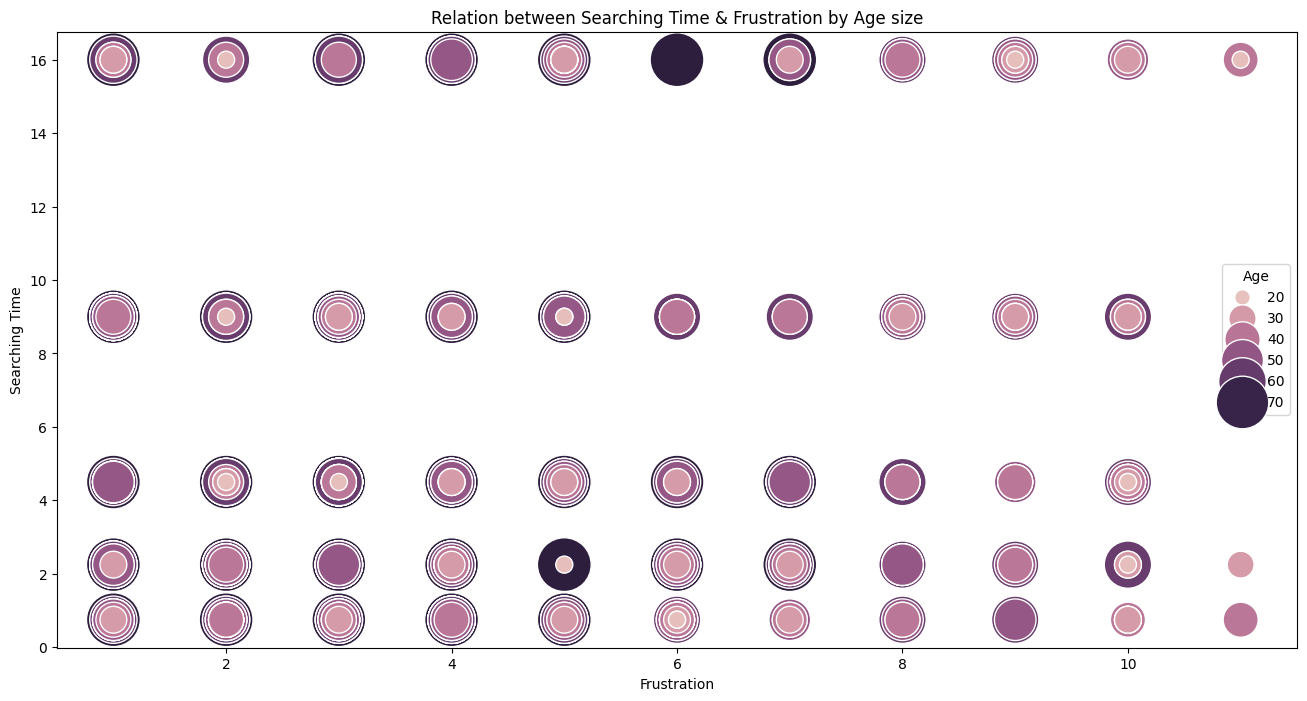

In [44]:
plt.figure(figsize=(16,8))
sns.scatterplot(df, y='TimeSearching', x='F_count', size='Age', sizes=(20,1500), hue='Age')
plt.title('Relation between Searching Time & Frustration by Age size')
plt.xlabel('Frustration')
plt.ylabel('Searching Time')

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [45]:
q='''
SELECT DatabaseWantToWorkWith
FROM main
'''
df=pd.read_sql_query(q, conn)

In [46]:
df.dropna()

,DatabaseWantToWorkWith
1,PostgreSQL
2,Firebase Realtime Database
3,MongoDB;MySQL;PostgreSQL
4,PostgreSQL;SQLite
5,Cloud Firestore
...,...
65421,Dynamodb
65427,BigQuery;Cassandra;Databricks SQL;DuckDB;Elast...
65431,Elasticsearch;PostgreSQL;Redis
65435,PostgreSQL;SQLite


In [47]:
df['DatabaseWantToWorkWith']=df['DatabaseWantToWorkWith'].str.split(';')
df=df.explode('DatabaseWantToWorkWith').reset_index(drop=True)

In [48]:
df['DatabaseWantToWorkWith'].count()

np.int64(127439)

In [49]:
df['Count']=1

In [50]:
gr=df.groupby('DatabaseWantToWorkWith').sum()

In [51]:
gr=gr.sort_values(by='Count', ascending=False).head(5)

In [52]:
gr

,Count
DatabaseWantToWorkWith,
PostgreSQL,24005
SQLite,13489
MySQL,12269
MongoDB,10982
Redis,10847


<Figure size 1600x600 with 0 Axes>

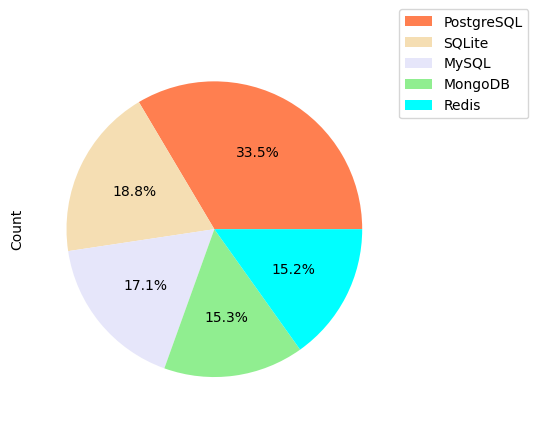

In [53]:
lab=gr.index
col=['coral', 'wheat', 'lavender', 'lightgreen', 'cyan']
plt.figure(figsize=(16,6))
gr.plot(kind='pie', subplots=True,
        labels=None,
        autopct='%1.1f%%',
        colors=col
       )
plt.legend(lab, loc=(1, 0.8))

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 29 to 40 .


In [111]:
## Write your code here
q='''
SELECT TimeSearching, TimeAnswering, Age
FROM main
'''
df=pd.read_sql_query(q, conn)

In [112]:
df.isnull().sum()

TimeSearching    36526
TimeAnswering    36593
Age                  0
dtype: int64

In [113]:
df['TimeAnswering'].value_counts()

TimeAnswering
15-30 minutes a day           9341
30-60 minutes a day           8642
Less than 15 minutes a day    5918
60-120 minutes a day          3704
Over 120 minutes a day        1239
Name: count, dtype: int64

In [114]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

time_map={'Less than 15 minutes a day' : 7.5,
          '15-30 minutes a day' : (30+15)/2,
          '30-60 minutes a day' : (30+60)/2,
          '60-120 minutes a day' : (60+120)/2,
          'Over 120 minutes a day' :(120+200)/2}
df['TimeSearching']=df['TimeSearching'].map(time_map)
df['TimeAnswering'] =df['TimeAnswering'].map(time_map)

In [116]:
df['Age'].unique()

array([16. , 39.5, 49.5, 21. , 29.5, 59.5,  nan, 72.5])

In [99]:
df.dropna(inplace=True)

In [117]:
df = df[(df['Age'] >= 29)&(df['Age'] <= 40)]

In [118]:
df

,TimeSearching,TimeAnswering,Age
1,NaN,NaN,39.5
6,NaN,NaN,39.5
9,NaN,NaN,39.5
10,45.0,90.0,39.5
12,45.0,22.5,39.5
...,...,...,...
65424,NaN,NaN,29.5
65427,NaN,NaN,29.5
65428,NaN,NaN,29.5
65433,NaN,NaN,29.5


In [119]:
df=df.groupby(['Age'])[['TimeSearching', 'TimeAnswering']].median()

<Axes: xlabel='Age'>

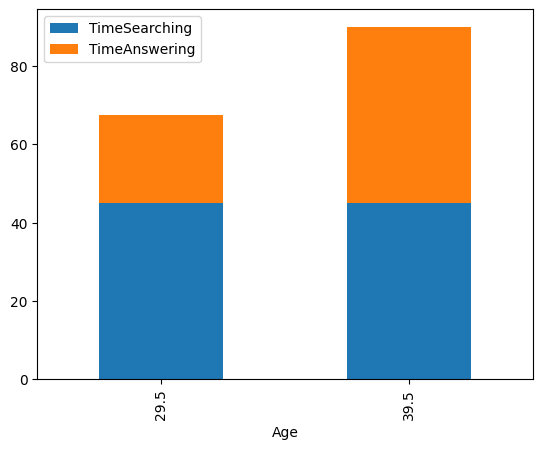

In [120]:
df.plot(kind='bar', stacked=True)

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [121]:
conn = sqlite3.connect('survey-data.sqlite')
q='''
SELECT CompTotal, Age
FROM main
'''
df=pd.read_sql_query(q, conn)

In [122]:
age_map = {'35-44 years old': (44+35)/2,
           'Under 18 years old' : 16,
           '18-24 years old' : (24+18)/2,
           '25-34 years old' : (34+25)/2,
           '45-54 years old' : (54+45)/2,
           '55-64 years old' : (64+55)/2,
           '65 years or older' : (65+80)/2}
df['Age'] = df['Age'].map(age_map)

In [123]:
df.isnull().sum()

CompTotal    31697
Age            322
dtype: int64

In [124]:
df=df.dropna()

In [125]:
df = df[(df['Age'] >= 45)&(df['Age'] <= 60)]

In [126]:
df = df.groupby(['Age']).median()

Text(0, 0.5, 'Compensation')

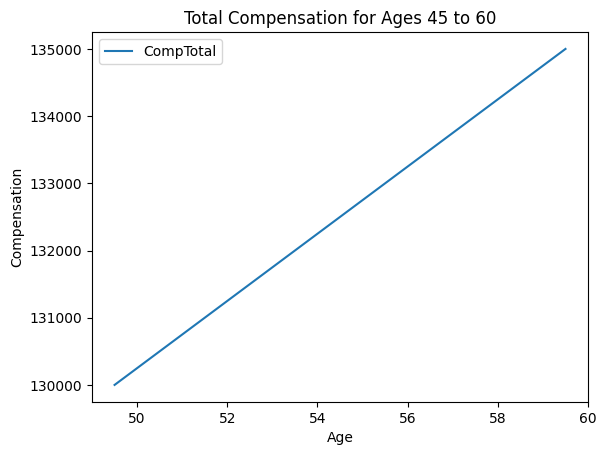

In [129]:
df.plot()
plt.title('Total Compensation for Ages 45 to 60')
plt.ylabel('Compensation')

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [130]:
## Write your code here
q='''
SELECT MainBranch
FROM main
'''
df=pd.read_sql_query(q, conn)

In [132]:
df['Count'] = 1

In [134]:
df=df.groupby(['MainBranch']).sum()

<Axes: ylabel='MainBranch'>

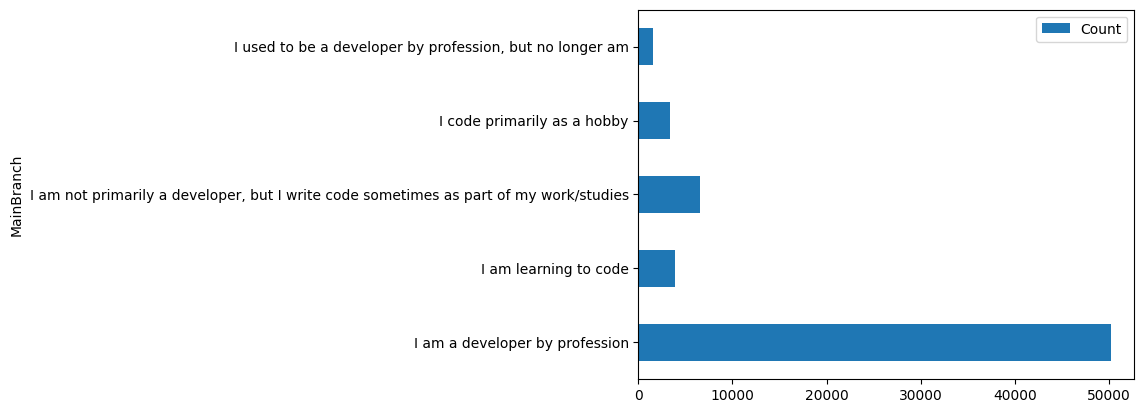

In [136]:
df.plot(kind='barh')
plt.title('

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [65]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
